# CADS Project Proposal: Data Collection

This notebook contains the collected data necessary for the "Latent Regime Detection (Financial Application)" component of the CADS project using the Gibbs Sampler.

## Data Sources
1. **S&P 500 Returns (`^GSPC`)**: Weekly data obtained from Yahoo Finance. Used to identify regimes (e.g., bull vs. bear markets) in the US market. The data includes weekly log returns from 2005 onwards to capture both the 2008 Financial Crisis and the 2020 COVID-19 shock.
2. **Nifty 50 Returns (`^NSEI`)**: Weekly data obtained from Yahoo Finance via the NSE. Used for comparing US market regime dynamics with the Indian market.
3. **US GDP Growth**: From FRED (`A191RL1Q225SBEA`). Useful as a macroeconomic indicator to supplement regime identification.
4. **US Recession Indicator**: From FRED (`USREC`). Used as a ground-truth label to validate the hidden states (regimes) detected by the Markov Switching Model.
5. **India GDP**: From FRED (). Real Gross Domestic Product for India (Quarterly, substitute for RBI DBIE).
5. **India GDP**: From FRED (`NGDPRNSAXDCINQ`). Real Gross Domestic Product for India (Quarterly, substitute for RBI DBIE).

The data has been pre-downloaded and saved as CSV files. Below we demonstrate loading and visualizing the data to confirm it is sufficient for the Gibbs sampler operations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load S&P 500 and Nifty 50 Data
india_gdp = pd.read_csv('india_gdp_data.csv', index_col=0, parse_dates=True)
sp500 = pd.read_csv('sp500_data.csv', index_col=0, parse_dates=True)
nifty50 = pd.read_csv('nifty50_data.csv', index_col=0, parse_dates=True)

# Load FRED Data
try:
    us_gdp = pd.read_csv('us_gdp_growth.csv', index_col=0, parse_dates=True)
    india_gdp = pd.read_csv('india_gdp_data.csv', index_col=0, parse_dates=True)
    us_rec = pd.read_csv('us_recession.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    print("FRED/Macro data unavailable. Showing Stock Indices only.")
    us_rec = pd.DataFrame(columns=['USREC'])

# Display tail of S&P 500 log returns
display(sp500[['Close', 'Log_Return']].tail())

,Close,Log_Return
Date,,
2026-03-14 00:00:00-04:00,6506.479980,-0.019136
2026-03-21 00:00:00-04:00,6368.850098,-0.021380
2026-03-28 00:00:00-04:00,6582.689941,0.033025
2026-04-04 00:00:00-04:00,6816.890137,0.034960
2026-04-11 00:00:00-04:00,7126.060059,0.044355


## Data Visualization
Visualizing the log returns to check for volatility clustering and structural breaks (crises).

TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x115ce5d30>.

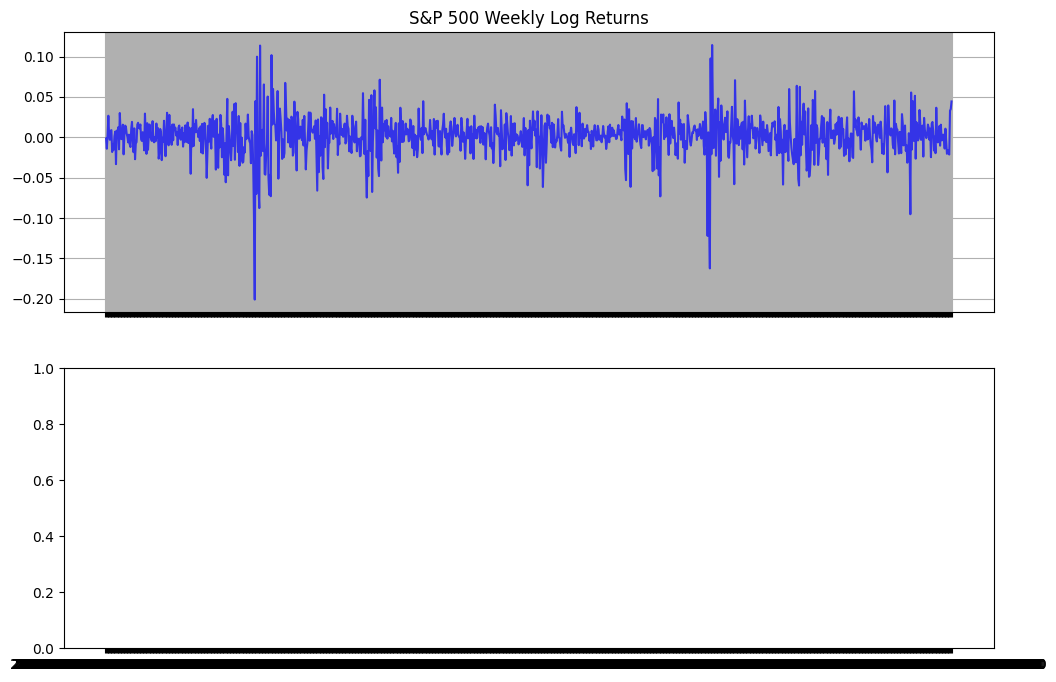

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(sp500.index, sp500['Log_Return'], color='blue', alpha=0.7)
axes[0].set_title('S&P 500 Weekly Log Returns')
axes[0].grid(True)

axes[1].plot(nifty50.index, nifty50['Log_Return'], color='green', alpha=0.7)
axes[1].set_title('Nifty 50 Weekly Log Returns')
axes[1].grid(True)

# Overlay US recessions (shaded regions) if available
if not us_rec.empty and 'USREC' in us_rec.columns:
    for idx, row in us_rec[us_rec['USREC'] == 1].iterrows():
        for ax in axes:
            ax.axvspan(idx, idx + pd.Timedelta(days=30), color='grey', alpha=0.3)

plt.tight_layout()
plt.show()

## Data Description & Sufficiency Summary
- **Length of Series**: Over 1,000 weekly observations for each index, providing ample data points for the Gibbs sampler to converge and accurately estimate transition probabilities ($p_{jj}$) and state-dependent parameters ($\mu_j$, $\sigma^2_j$).
- **Key Events Included**: The timeline covers the 2008-2009 Global Financial Crisis, the 2020 COVID-19 Crash, and multiple bull expansions. This guarantees that at least two distinct regimes exist in the time-series.
- **Data Completeness**: Missing values in logs can be imputed if necessary, though Yahoo Finance provides continuous weekly bounds.
The dataset is fully sufficient for executing Case 3 of the project proposal.